T-Rex running in High Flux mode, with cententral wavelength = 2.50 Å, RRM = 12.
Pulse shaping chopper frequency = 126 Hz, Monochromatic chopper frequency = 168 Hz


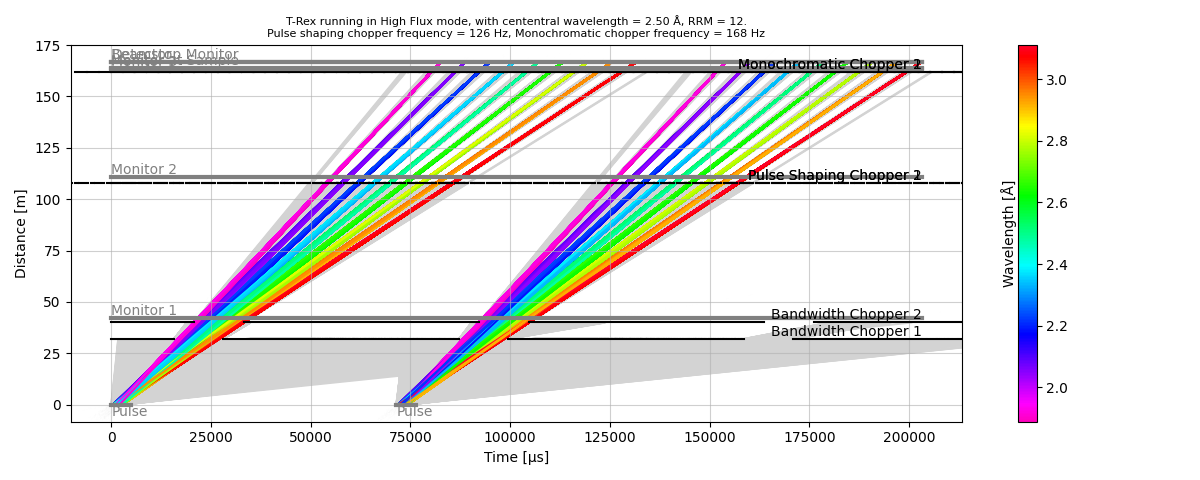

In [1]:
%matplotlib widget
import tof
import scipp as sc
from trex.instrument import Instrument
import matplotlib.pyplot as plt

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 12  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
trex.source = tof.Source(facility="ess", neutrons=5_000_000, pulses=2)  # type: ignore
print(trex)
res = trex.model.run()
p = res.plot(visible_rays=1_000_000, blocked_rays=50_000)

p.ax.set_title(trex, fontsize=8)
p.ax.grid(alpha=0.6)
p.fig.tight_layout()

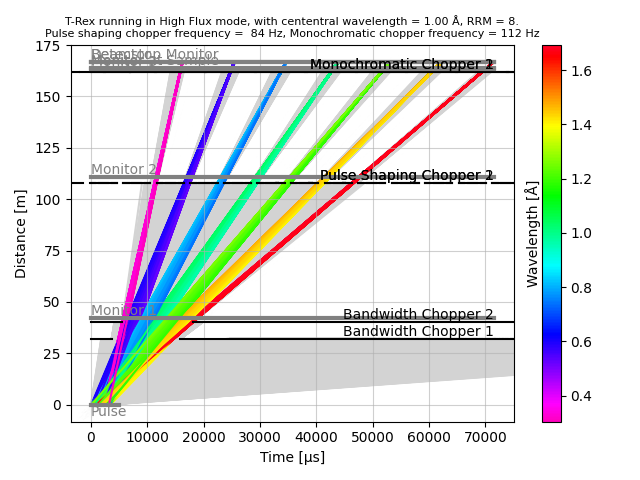

In [2]:
T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(1, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
res = trex.model.run()
p = res.plot(visible_rays=500_000, blocked_rays=50_000)

p.ax.set_title(trex, fontsize=8)
p.ax.grid(alpha=0.6)
p.fig.tight_layout()

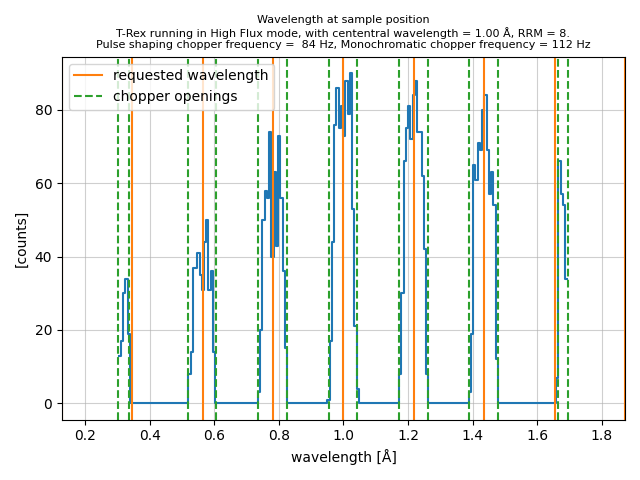

In [3]:
T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(1, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode

trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

fig, ax = plt.subplots()
events_at_sample.hist(wavelength=200).plot(ax=ax)
ax.set_title("Wavelength at sample position\n" + str(trex), fontsize=8)

delta_lambda = trex.calculate_delta_lambda()
# plot expected Ei wavelength
lambda_i = [
    trex.wavelength,
]
for i in range(1, trex.rrm // 2 + 1):
    lambda_i.append(trex.wavelength - delta_lambda * i)
    lambda_i.append(trex.wavelength + delta_lambda * i)
# lambda_i = trex.calculate_incoming_wavelength()
lambda_i_bounds_low, lambda_i_bounds_high = trex.calculate_incoming_wavelength_bounds()


for w in lambda_i_bounds_low:
    vline_bw = ax.axvline(x=w.values, c="C2", linestyle="--")
for w in lambda_i_bounds_high:
    vline_bw = ax.axvline(x=w.values, c="C2", linestyle="--")
for lam in lambda_i:
    vline_i = ax.axvline(x=lam.values, c="C1", linestyle="-")

ax.legend([vline_i, vline_bw], ["requested wavelength", "chopper openings"])
ax.set_xlim(min(lambda_i).values, max(lambda_i).values)
ax.grid(alpha=0.6)
fig.tight_layout()

In [4]:
trex.calculate_incoming_energy()

<scipp.Variable> (energy: 7)    float64            [meV]  [683.738, 257.233, ..., 39.6665, 29.8985]